# Imaging Through the Optics of the Eye


This notebook follows on from the previous notebook to show how the techniques described previously with `aotools` can be used in vision science.  

Aberrations in the human eye originate from the cornea, lens, tear film, aqueous/vitreous fluids, and deformations in the eye structure.  In vision science we typically correct for the first 10 Zernike orders.  By far the biggest contributions are from tip, tilt and defocus, but astigmatism and coma are also common.  Higher order aberrations are more common in older eyes.

Optical aberrations change with a temporal frequency of 5-6 Hz (due to accommodation, eye movements, changes in tear film).

Note that this only deals with monochromatic aberrations in the eye

- Create an aberrated PSF using real data from a dataset of human eyes $^a$
- Apply this to an extended image of retinal cells (simulated using ERICA) $^b$

<i>a) Jessica Jarosz, Pedro Mecê, Jean-Marc Conan, Cyril Petit, Michel Paques, and Serge Meimon,"High temporal resolution aberrometry in a 50-eye population and implications for adaptive optics error budget", Biomed. Opt. Express 8, 2088-2105 (2017) 

    
b) Laura K. Young and Hannah E. Smithson, "Emulated retinal image capture (ERICA) to test, train and validate processing of retinal images", Sci Rep 11, 11225 (2021)   
</i>

In [1]:
import numpy
import matplotlib.pylab as plt
from tqdm import tqdm, trange, tqdm_notebook
from astropy.io import fits
%matplotlib inline
import aotools


from matplotlib import animation, rc
from IPython.display import HTML
import matplotlib.colors as colors
import PIL.Image as Image

import scipy.signal
j = 0+1j
nx_size=128 #this might be too low - see below

Again we import the same modules as before, without the turbulence modules.  Here we will be importing a dataset (very kindly shared by Pedro Mecê) taken from 50 human eyes at a frequency of 236 Hz for a duration of 3.4 seconds.  

In [2]:
fitsdata = fits.open('tabai5mm.fits')
data=fitsdata[0].data

l=833e-3 #(this is the wavelength data was taken at in microns)
ln=833e-9 #(wavelength in nanometres - we'll use this later)
D=5e-3 #(pupil diameter in m)

This is a 50x808x65 matrix, where 50 is the number of eyes, 808 is the number of temporal points and 65 is the number of Zernike modes.  Note that Noll indexing is used here and the data is given in microns. 

The data has a very high amount of tip ($Z_{-1}^{1}$) aberration in it for all the eyes studied - about -9 microns.  This is probably due to the fixation target being at an angle to the person's eyes.  However, in the AOSLO, tip and tilt are not generally an issue as the system is double pass, and so eye movements don't contribute much to the overall aberration in the eye.  We tend to just subtract these when correcting for aberrations in the AOSLO. 

Here the tip/tilt aberrations are drowning out a lot of the useful higher order aberration data, which gives us information on the cornea and lens contributions to visual aberrations.  I've removed piston, tip and tilt from the data below to compensate for this.

In [3]:
data[:,:,0:2]=0

Lets just look at the wavefront for the first eye at time t=0 for now.  Aotools needs data in radians, so don't forget to convert from microns to radians!

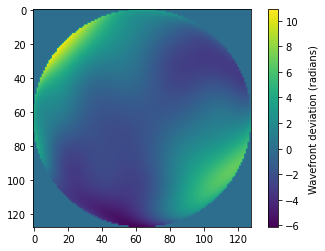

In [4]:
#create an array of Zernike modes
z=aotools.zernikeArray(65,nx_size)

z2 = numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))

wavefront = numpy.dot(((data[0,0,:])/l)*2*numpy.pi,z2)

wavefront = numpy.reshape(wavefront, (z.shape[1],z.shape[2]))
wavefront *= aotools.circle(nx_size/2, nx_size)

plt.figure()
plt.imshow(wavefront)
cbar = plt.colorbar()
cbar.set_label('Wavefront deviation (radians)', labelpad=8)

It's important to check that the wavefront is correctly sampled.  The Marechal criterion states that the maximum rms wavefront error for an optical system to be well-corrected is $\frac{\lambda}{14}$.  We don't want the maximum gradient between neighbouring pixels to be too high as we want a smoothly varying wavefront - this gradient can be quantified as an amplitude of tip or tilt.  The peak-to-valley wavefront error for tip and tilt corresponding to an rms of $\frac{\lambda}{14}$ is $\frac{\lambda}{3.5}$.  To be cautious, we use $\frac{\lambda}{7}$.

(Supplementary material - L.K.Young and H.E.Smithson, Front.Psychol. Vol. 5, pp. 1060, 2014)



In [5]:
#don't forget to convert back to microns for this bit

wavefrontm = numpy.dot((data[0,0,:]),z2)
wavefrontm = numpy.reshape(wavefront, (z.shape[1],z.shape[2]))
wavefrontm *= aotools.circle(nx_size/2, nx_size)

shift_x = numpy.roll(wavefrontm, -1, axis = 1)
shift_y = numpy.roll(wavefrontm, -1, axis = 0)

# Calculate the gradient of the wavefront using the difference quotient.
gradient_x = wavefrontm[1:-1, 1:-1] - shift_x[1:-1, 1:-1]
gradient_y = wavefrontm[1:-1, 1:-1] - shift_y[1:-1, 1:-1]

# Create a circular mask that is 2 pixels smaller than the aperture to 
# remove the gradients calculated at the edges of the wavefront, where 
# there is a discontinuity.
circle = aotools.circle((nx_size-2)/2, nx_size-2)

# Find the maximum gradient in either dimension.
max_gradient = max([abs(gradient_x * circle).max(),
                    abs(gradient_y * circle).max()])

# Check calculate the maximum gradient divided by the tolerance.
wavefront_check = max_gradient / (l/7)

if wavefront_check >1:
    print('Max gradient over tolerance (%.2f>1) - wavefront sampling is too low' %(wavefront_check))
else:
    print('Max gradient under tolerance (%.2f<1) - wavefront sampling is ok' %(wavefront_check))

Max gradient over tolerance (7.08>1) - wavefront sampling is too low


So we're probably going to end up with some artefacts here.  For the sake of speed in this session I've kept it as it is (more pixels = more computation time), but bear this in mind for actual simulations!

So now we can do same as we did before for the atmospheric turbulence.  

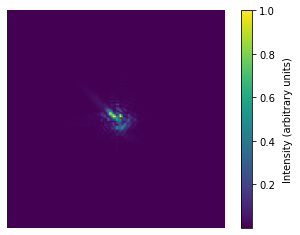

In [6]:
complex_phase = numpy.exp(j*wavefront)
oversampling_factor = 2 #oversampling should be at least 2
y=nx_size*oversampling_factor 

# Create padding to get an oversampled psf at the end to make it look nice
padded_pupil = numpy.zeros((y, y), dtype=numpy.complex64)
padded_pupil[:nx_size, :nx_size] = complex_phase

# Use AOtools to transform from the pupil to the focal plane
psf = numpy.abs(aotools.ft2(padded_pupil, delta=D/nx_size))**2
# Cut out the centre of the psf array for prettier plotting
psf_cut = psf[int(y/2-nx_size/2):int(y/2+nx_size/2), int(y/2-nx_size/2):int(y/2+nx_size/2)]


# normalise the PSF
psf_cut = psf_cut/numpy.max(psf_cut)

# Plot the PSF

plt.figure()
plt.imshow(numpy.abs(psf_cut))
plt.axis('off')
cbar = plt.colorbar()
cbar.set_label('Intensity (arbitrary units)', labelpad=8)

Lets do this over the full time range of 3.4s to get an average.

In [7]:
frames=len(data[0,:,0])
psfs = numpy.zeros((frames, y, y))

for n in tqdm(range(frames)):
    
    wf = numpy.dot((data[0,n,:]*2*numpy.pi)/l,z2)
    wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
    wf*=aotools.circle(nx_size/2, nx_size)
    padded_pupil[:nx_size, :nx_size] = numpy.exp(j*wf)
    psf = numpy.abs(aotools.ft2(padded_pupil, delta=D/nx_size))**2.
    psfs[n] = numpy.copy(psf)

average_psf = psfs.mean(0)

100%|███████████████████████████████████████████████████████████████████████████████| 808/808 [00:04<00:00, 193.65it/s]


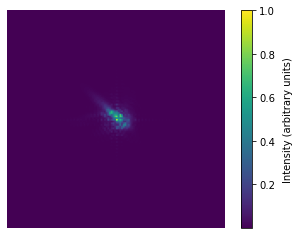

In [8]:
# Cut out the centre of the psf array for prettier plotting
psf_cut = average_psf[int(y/2-nx_size/2):int(y/2+nx_size/2), int(y/2-nx_size/2):int(y/2+nx_size/2)]
psf_cut = psf_cut/(numpy.max(psf_cut))
# Plot the PSF
plt.figure()
plt.imshow(numpy.abs(psf_cut))
plt.axis('off')

cbar = plt.colorbar()
cbar.set_label('Intensity (arbitrary units)', labelpad=8)

Eye aberrations are less dynamic than atmospheric ones.  Let's see how the wavefront and psf change over time

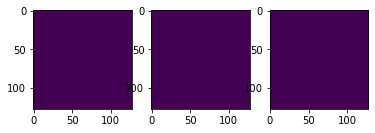

In [9]:
frames=len(data[0,:,0])
psfs = numpy.zeros((frames, y, y))

padded_pupil = numpy.zeros((y, y), dtype=numpy.complex64)


# Video of moving a phase screen and PSF
fig, [ax1, ax2, ax3] = plt.subplots(nrows=1, ncols=3)
screen_image = ax1.imshow(numpy.zeros((nx_size, nx_size)))
psf_image = ax2.imshow(numpy.zeros((nx_size, nx_size)))
average_image = ax3.imshow(numpy.zeros((nx_size, nx_size)))

def init():
    screen_image.set_data(numpy.zeros((nx_size, nx_size)))
    psf_image.set_data(numpy.zeros((nx_size, nx_size)))
    average_image.set_data(numpy.zeros((nx_size, nx_size)))
    return (screen_image, psf_image, average_image,)

def animate(i):  
    z=aotools.zernikeArray(66,nx_size)
    z=z[1:,:,:] # the values start at tip/tilt
    
    z2 = numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))

    wavefront = numpy.dot((data[0,i,:]*2*numpy.pi)/l,z2)
    wavefront = numpy.reshape(wavefront, (z.shape[1],z.shape[2]))
    
    
    screen_image.set_data(wavefront*aotools.circle(nx_size/2, nx_size))
    screen_image.autoscale()
    
    padded_pupil[:nx_size, :nx_size] = numpy.exp(j*wavefront*aotools.circle(nx_size/2, nx_size))
    
    # Use AOtools to transform from the pupil to the focal plane
    psf = numpy.abs(aotools.ft2(padded_pupil, delta=D/nx_size))**2.
    
    psf_cut = psf[int(y/2-nx_size/2):int(y/2+nx_size/2), int(y/2-nx_size/2):int(y/2+nx_size/2)]
    psf_cut = psf_cut/(numpy.max(psf_cut))
    psf_image.set_data(psf_cut)
    psf_image.autoscale()
    
    psfs[i] = numpy.copy(psf)
    average_psf = psfs[:i+1].mean(0)
    average_psf_cut = average_psf[int(y/2-nx_size/2):int(y/2+nx_size/2), int(y/2-nx_size/2):int(y/2+nx_size/2)]
    average_psf_cut = average_psf_cut/(numpy.max(average_psf_cut))
    average_image.set_data(average_psf_cut)
    average_image.autoscale()
    
    return (screen_image, psf_image, average_image)

anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=frames, interval=50, 
                               blit=True)

In [10]:
HTML(anim.to_html5_video())

The data was taken at 236Hz - here I've slowed it down to 20Hz.  Between 22 and 27 seconds you can see the eye defocusing (this is about 100 frames - ie about 0.4 seconds at 236 Hz).  This is most likely the eye accommodating.

Lets look at how the psfs change between different eyes.  We'll have a look at the first fifteen.

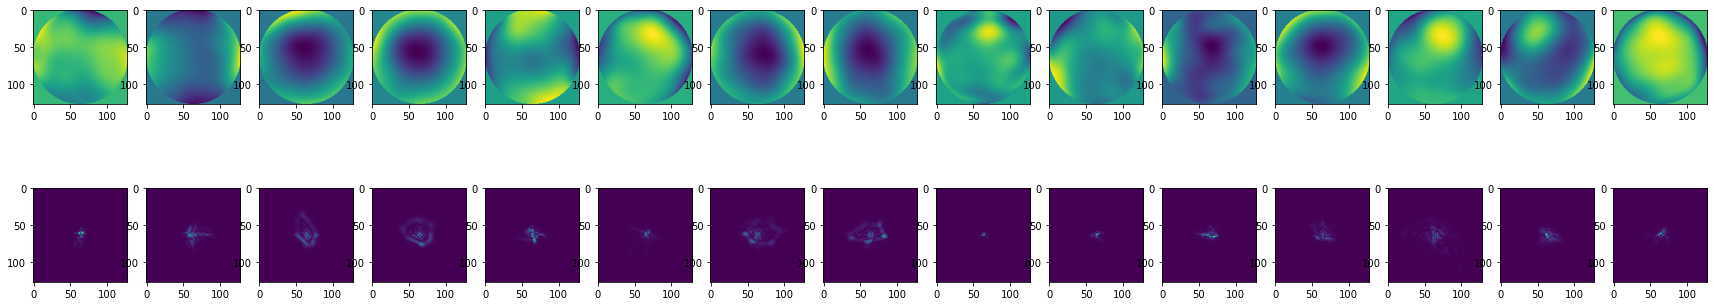

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=15)
z=aotools.zernikeArray(66,nx_size)
z=z[1:,:,:] # the values start at tip/tilt
fig.set_size_inches(30, 6)
z2 = numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))

for n in range(15):
    wavefront = numpy.dot((data[n,0,:]*2*numpy.pi)/l,z2)
    wavefront = numpy.reshape(wavefront, (z.shape[1],z.shape[2]))
    wavefront *= aotools.circle(nx_size/2, nx_size)
    ax[0,n].imshow(wavefront)
    padded_pupil[:nx_size, :nx_size] = numpy.exp(j*wavefront)
    
    # Use AOtools to transform from the pupil to the focal plane
    psf = numpy.abs(aotools.ft2(padded_pupil, delta=D/nx_size))**2.
    
    psf_cut = psf[int(y/2-nx_size/2):int(y/2+nx_size/2), int(y/2-nx_size/2):int(y/2+nx_size/2)]
    psf_cut = psf_cut/(numpy.max(psf_cut))
    ax[1,n].imshow(psf_cut)
      

(You might like to double click the plots to see them a bit bigger)

## Applying this to AOSLO images

Lets apply our PSF from the first eye to an image of the retina.  This is a ground truth image obtained using ERICA$^{b}$ - a retinal image simulation tool.  We obtained this simulating a 5mm pupil at the fovea, with a field of view of 2 degrees.

Typically we image over a 1-2 $^{\circ}$ square patch of retina.  We make the assumption that the optical system is isoplanatic - so the PSF is the same for all points in the square patch of retina.

It is important that the pixel scales of the psf and source image match up.  I used an oversampling value of 2 in the above code, but that probably won't match to our image.  We can check this:

In [23]:
oversampling = y/nx_size

#check the size of the psf
pixel_scale_psf = (ln)/(oversampling*D) 
#then convert it to arcminutes
pixel_scale_psf_arcminutes = (pixel_scale_psf * 180.0 * 60)/ numpy.pi

print('The pixel scale of the psf in arcminutes is: %f'%pixel_scale_psf_arcminutes)


The pixel scale of the psf in arcminutes is: 0.286364


Open the image to find number of image pixels

uint8
Number of pixels = 545 x 545


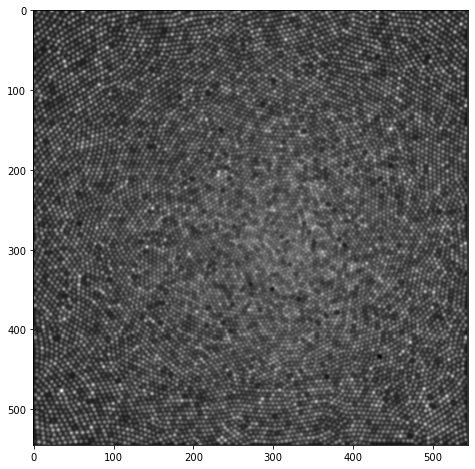

In [24]:
#Open the image
image = Image.open('foveatedretina.bmp') #This is a simulated retinal image from ERICA
image = numpy.array(image)
if image.shape[0] < image.shape[1]:
    image = image[:,:image.shape[0]]
elif image.shape[1] < image.shape[0]:
    image = image[:,:image.shape[0]]
#this makes sure the image is square!
print(image.dtype)
plt.figure(figsize=(8,8))
plt.imshow(image,cmap='gray')
print('Number of pixels = %i x %i'%(image.shape[0],image.shape[1]))

In [27]:
fov_arcmin = 120 #The field of view of our image is 2 degrees 

n_pixels_image = image.shape[0]
pixel_scale_image_arcmin = fov_arcmin / n_pixels_image 
print('The pixel scale of the image in arcminutes is: %f'%pixel_scale_image_arcmin)

if pixel_scale_image_arcmin != pixel_scale_psf_arcminutes:
    print ('Pixel scales do not match - need to change oversampling')

new_oversampling = (oversampling * pixel_scale_psf_arcminutes) / pixel_scale_image_arcmin
pixel_scale_psf = ln/(new_oversampling*D) 
pixel_scale_psf_arcminutes = pixel_scale_psf * 180.0 * 60/ numpy.pi
print('The pixel scale of the psf in arcminutes is now: %f'%pixel_scale_psf_arcminutes)
print('The new oversampling value is %.2f'%(new_oversampling))


The pixel scale of the image in arcminutes is: 0.220183
Pixel scales do not match - need to change oversampling
The pixel scale of the psf in arcminutes is now: 0.220183
The new oversampling value is 2.60


Lets use our new oversampling rate to find the psf again and then convolve it with our image

In [28]:
psfs = numpy.zeros((frames, int(new_oversampling*nx_size), int(new_oversampling*nx_size)))
padded_pupil = numpy.zeros((int(new_oversampling*nx_size), int(new_oversampling*nx_size)), dtype=numpy.complex64)
print(psfs.shape)

frames=len(data[0,:,0])
for n in tqdm(range(frames-1)):
    
    wf = numpy.dot((data[0,n,:]*2*numpy.pi)/l,z2)
    wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
    wf*=aotools.circle(nx_size/2, nx_size)
    padded_pupil[:nx_size, :nx_size] = numpy.exp(j*wf)
    psf = numpy.abs(aotools.ft2(padded_pupil,delta=D/nx_size))**2.
    psfs[n] = numpy.copy(psf)




  1%|▌                                                                                 | 6/807 [00:00<00:14, 56.29it/s]

(808, 332, 332)


100%|████████████████████████████████████████████████████████████████████████████████| 807/807 [00:14<00:00, 56.28it/s]


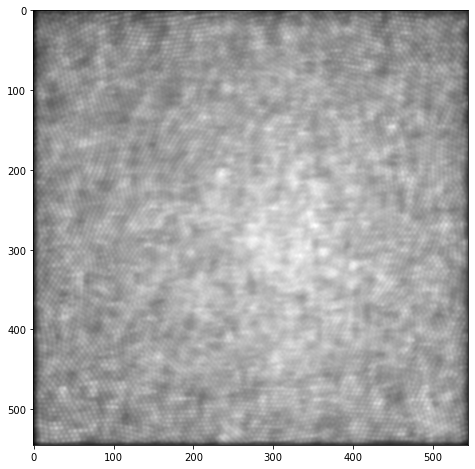

In [29]:
plt.figure(figsize=(8,8))
plt.imshow(scipy.signal.convolve2d(image,psfs[0],mode='same'),cmap='gray')


Note the edges have artefacts.  We can remove those if we use boundary wrapping

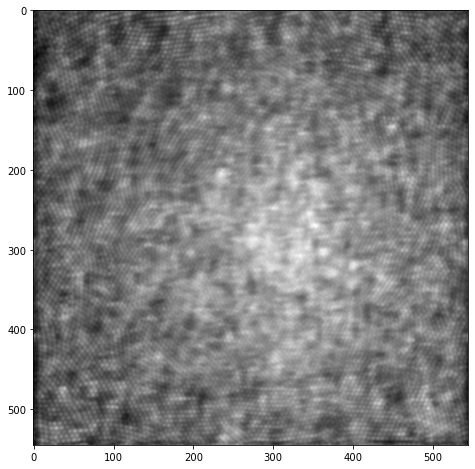

In [30]:
plt.figure(figsize=(8,8))
plt.imshow(scipy.signal.convolve2d(image,psfs[0],mode='same',boundary='wrap'),cmap='gray')

This is a very basic method of applying aberrations to an image of the retina.  In reality, if we were imaging with an AOSLO, the confocal pinhole and scanning of the system also affect the image of the retina we obtain.

## The modulation transfer function

In retinal imaging, we are interested in whether we can resolve rods and cones in an image. Thus it is important to quantify how spatial frequencies are transmitted through the eye's optics, including any aberrations. The modulation transfer function is the power spectrum of the PSF and characterises the proportion of contrast present in the object that is preserved in the image formed by an optical system

Lets look at the psf at time zero for the first eye again

(332, 332)


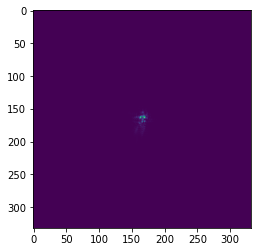

In [31]:
plt.imshow(psfs[0])
print (psfs[0].shape)

The MTF is just the modulus of the fourier transform of the PSF

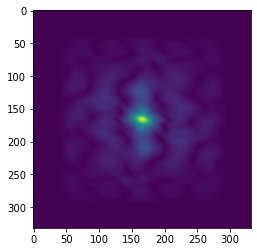

In [32]:
mtf = numpy.abs(aotools.fouriertransform.ft2(psfs[0],D/nx_size))
plt.imshow(mtf)

We can compare this to the MTF for a diffraction limited PSF with the same size pupil

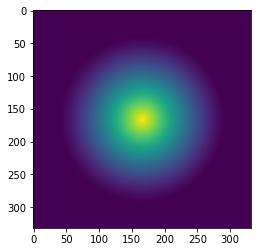

In [33]:
pixel_scale_psf_deg=pixel_scale_psf_arcminutes/60
dlcomplex_phase = numpy.exp(j*0)*aotools.circle(nx_size/2, nx_size)

dlpadded_pupil = numpy.zeros((int(new_oversampling*nx_size), int(new_oversampling*nx_size)), dtype=numpy.complex64)
dlpadded_pupil[:nx_size, :nx_size] = dlcomplex_phase

dlpsf = numpy.abs(aotools.ft2(dlpadded_pupil, delta=D/nx_size))**2
dlmtf = numpy.abs(aotools.fouriertransform.ft2(dlpsf,delta=pixel_scale_psf_deg))

dlmtf1d = aotools.azimuthal_average(dlmtf)
plt.imshow(dlmtf)


Lets plot the MTF against spatial frequencies for the first eye:

(0.0, 1.0)

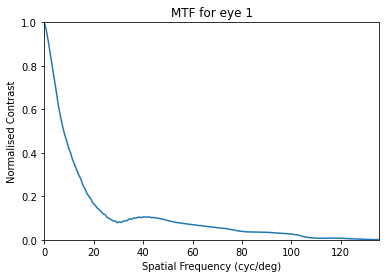

In [34]:
spatial_scales = numpy.fft.fftshift(numpy.fft.fftfreq(mtf.shape[0],pixel_scale_psf_deg))[int(mtf.shape[0]*0.5):]
mtf1d = aotools.azimuthal_average(mtf)
plt.plot(spatial_scales,mtf1d/max(mtf1d))
plt.title('MTF for eye 1')
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)

The cut-off frequency where the contrast falls to zero is given by $\frac{\text{pupil size}}{\text{wavelength}}$ - don't forget to convert this to cycles per degree.  The cutoff frequency is higher for larger pupil diameters, and thus a higher pupil diameter increases visual resolution.  This is why when taking retinal images we tend to dilate the pupil.

In [35]:
cf=((D/ln))*(numpy.pi/180)
print('cut-off frequency = %f cycles per degree'%cf)

cut-off frequency = 104.761660 cycles per degree


This corresponds to a spatial scale of about 0.6 arcminutes

Let's plot both the real eye psf and the diffraction limited PSF and compare the two:

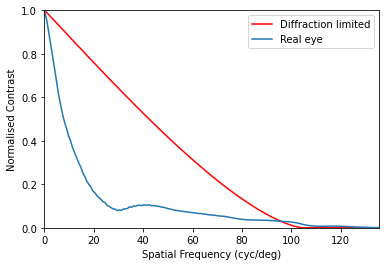

In [36]:
plt.plot(spatial_scales, dlmtf1d/max(dlmtf1d),color='red',label='Diffraction limited')
plt.plot(spatial_scales, mtf1d/max(mtf1d), label = 'Real eye')
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)
plt.legend()

As we can see, the MTF of the real eye decreases much more sharply than the diffraction limited MTF as spatial frequency increases.

This is a useful scale to help us quantify vision.  Lets try this with a few more eyes:

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:06<00:00,  1.46it/s]


(0.0, 1.0)

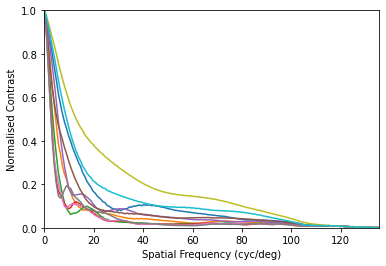

In [37]:
for n in tqdm(range(10)): #lets look at the first 10
    padded_pupil = numpy.zeros((int(new_oversampling*nx_size), int(new_oversampling*nx_size)), dtype=numpy.complex64)
    
    wf = numpy.dot((data[n,0,:]*2*numpy.pi)/l,z2)
    wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
    wf*=aotools.circle(nx_size/2, nx_size)
    padded_pupil[:nx_size, :nx_size] = numpy.exp(j*wf)
    psf2 = numpy.abs(aotools.ft2(padded_pupil,delta=D/nx_size))**2.
    mtf2 = abs(numpy.fft.fftshift(numpy.fft.fft2(psf2)))
    mtf1d2 = aotools.azimuthal_average(mtf2)
        
    
    sf = numpy.linspace(-numpy.floor(mtf2.shape[0]/2.), numpy.ceil((mtf2.shape[0]-1)/2.), mtf2.shape[0])
    plt.plot(spatial_scales, mtf1d2/max(mtf1d2))
    
plt.xlabel('Spatial Frequency (cyc/deg)')
plt.ylabel('Normalised Contrast')
plt.xlim(0,numpy.max(spatial_scales))
plt.ylim(0,1)

If we take into account the diffraction limit of the pupil and the cone spacing of the fovea, the highest frequency the human eye can really resolve is about 1 cycle per arcminute - or 60 cycles per degree (Hirsch et.al., Vision Res. Vol. 29, No. 9, pp. 1095-I 101, 1989).  